1. Data Import and Cleaning:

    - Import the dataset using Pandas.
    - Clean and preprocess the data, addressing missing values and categorizing data as needed.
    - Convert dates and other relevant fields to appropriate formats.


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin-1')
df

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,11/21/2022,10:15,"Medellín, Colombia",AeroPaca SAS,NaN,Medellín - Pizarro,Piper PA-31-350 Navajo Chieftain,HK-5121,31-7652004,8.0,6.0,2.0,8.0,6.0,2.0,0.0,The plane was chartered to carry a team of six...
4994,1/15/2023,10:50,"Pokhara, Nepal",Yeti Airlines,YT691,Kathmandu - Pokhara,ATR 72-500-72-212-A,9NANC,754,72.0,68.0,4.0,72.0,68.0,4.0,0.0,"Before approach, the pilot requested a change ..."
4995,9/16/2023,NaN,"Barcelos, Brazil",Manaus Aerotaxi,NaN,NaN,Embraer EMB-110P1 Bandeirante,PT-SOG,110490,14.0,12.0,2.0,14.0,12.0,2.0,0.0,The air taxi crashed in heavy rain while attem...
4996,10/29/2023,6:30,"Rio Branco, Brazil",ART Taxi Aero,NaN,Rio Branco - Envira,Cessna 208B Grand Caravan,PT-MEE,208B0344,12.0,10.0,2.0,12.0,10.0,2.0,0.0,The air taxi crashed into a heavy wooded area ...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Ground         

In [4]:
df.columns

Index(['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type',
       'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew',
       'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground',
       'Summary'],
      dtype='str')

In [5]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = df['Time'].fillna('0:00')

text_cols = ['Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Summary']
df[text_cols] = df[text_cols].fillna('Unknown')

num_cols = ['Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground']
df

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,Unknown,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1909-09-07,0:00,"Juvisy-sur-Orge, France",Unknown,Unknown,Air show,Wright Byplane,SC1,Unknown,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,Unknown,Unknown,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,1913-08-06,0:00,"Victoria, British Columbia, Canada",Private,Unknown,Unknown,Curtiss seaplane,Unknown,Unknown,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),Unknown,Unknown,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,2022-11-21,10:15,"Medellín, Colombia",AeroPaca SAS,Unknown,Medellín - Pizarro,Piper PA-31-350 Navajo Chieftain,HK-5121,31-7652004,8.0,6.0,2.0,8.0,6.0,2.0,0.0,The plane was chartered to carry a team of six...
4994,2023-01-15,10:50,"Pokhara, Nepal",Yeti Airlines,YT691,Kathmandu - Pokhara,ATR 72-500-72-212-A,9NANC,754,72.0,68.0,4.0,72.0,68.0,4.0,0.0,"Before approach, the pilot requested a change ..."
4995,2023-09-16,0:00,"Barcelos, Brazil",Manaus Aerotaxi,Unknown,Unknown,Embraer EMB-110P1 Bandeirante,PT-SOG,110490,14.0,12.0,2.0,14.0,12.0,2.0,0.0,The air taxi crashed in heavy rain while attem...
4996,2023-10-29,6:30,"Rio Branco, Brazil",ART Taxi Aero,Unknown,Rio Branco - Envira,Cessna 208B Grand Caravan,PT-MEE,208B0344,12.0,10.0,2.0,12.0,10.0,2.0,0.0,The air taxi crashed into a heavy wooded area ...


2. Exploratory Data Analysis:

    - Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
    - Analyze the frequency of crashes over time to identify any trends.


In [6]:
nb_crashes = len(df)
print("Nb crashes:", nb_crashes)

total_fatalities = df['Fatalities'].sum()
print("Nb victims:", total_fatalities)

total_aboard = df['Aboard'].sum()
print("Nb aboard:", total_aboard)

survival_rate = (total_aboard - total_fatalities) / total_aboard
print(f"Taux de survie global : {survival_rate:.2%}")

df[['Aboard', 'Fatalities', 'Ground']].describe()

Nb crashes: 4998
Nb victims: 111644.0
Nb aboard: 155356.0
Taux de survie global : 28.14%


,Aboard,Fatalities,Ground
count,4980.000000,4990.000000,4956.000000
mean,31.195984,22.373547,1.719128
std,45.534788,35.061741,55.540273
min,0.000000,0.000000,0.000000
25%,7.000000,4.000000,0.000000
50%,16.000000,11.000000,0.000000
75%,35.000000,25.000000,0.000000
max,644.000000,583.000000,2750.000000


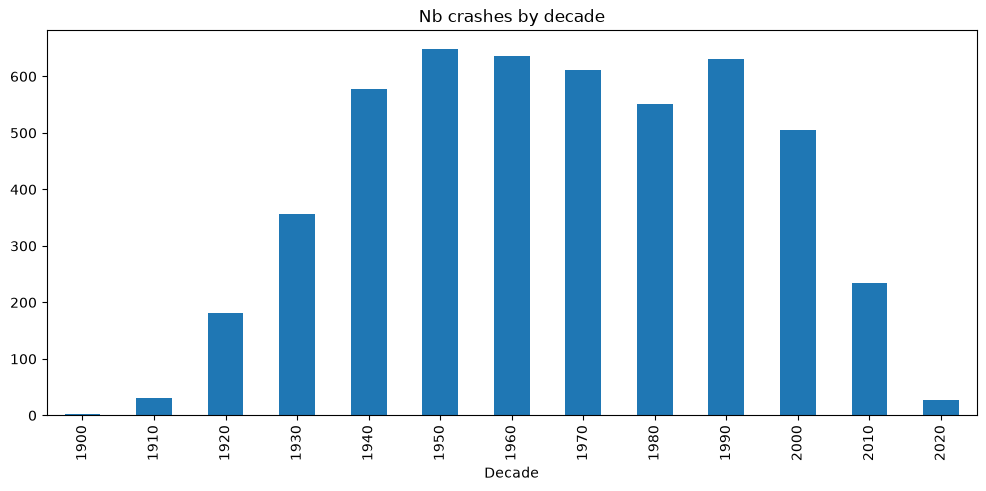

In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df['Decade'] = (df['Year'] // 10) * 10
df_decades = df.groupby('Decade').size()
df_decades.plot(kind='bar', figsize=(12, 5), title='Nb crashes by decade')
plt.show()

3. Statistical Analysis:

    - Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
    - Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).


In [8]:
fatalities = df['Fatalities'].dropna()

mean_fatal = np.mean(fatalities)
median_fatal = np.median(fatalities)
std_fatal = np.std(fatalities)
skew_fatal = stats.skew(fatalities)
kurt_fatal = stats.kurtosis(fatalities)

print(f"*** Fatalities ***")
print(f"Mean: {mean_fatal}")
print(f"Median: {median_fatal}")
print(f"Std: {std_fatal}")
print(f"Skew: {skew_fatal}")
print(f"Kurtosis: {kurt_fatal}")

*** Fatalities ***
Mean: 22.37354709418838
Median: 11.0
Std: 35.058227283246566
Skew: 4.606031652398515
Kurtosis: 36.59735922231812


In [9]:
survival_rate = ((df['Aboard'] - df['Fatalities']) / df['Aboard']).dropna()

mean_survival_rate = np.mean(survival_rate)
median_survival_rate = np.median(survival_rate)
std_survival_rate = np.std(survival_rate)

print(f"*** Survival rate ***")
print(f"Mean: {mean_survival_rate}")
print(f"Median: {median_survival_rate}")
print(f"Std: {std_survival_rate}")

*** Survival rate ***
Mean: 0.181489019431307
Median: 0.0
Std: 0.31169291860403087


In [10]:
stats.describe(fatalities)

DescribeResult(nobs=np.int64(4990), minmax=(np.float64(0.0), np.float64(583.0)), mean=np.float64(22.37354709418838), variance=np.float64(1229.325658091087), skewness=np.float64(4.606031652398515), kurtosis=np.float64(36.59735922231812))

In [11]:
from scipy import stats

year1 = 1950
year2 = 1960

group1 = df.loc[df['Decade'] == year1, 'Fatalities'].dropna()
group2 = df.loc[df['Decade'] == year2, 'Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

print("t-statistic :", t_stat)
print("p-value :", p_value)

alpha = 0.05
if p_value < alpha:
    print("p <", alpha, "-> reject H0")
else:
    print("p >=", alpha, "-> don't reject H0")

t-statistic : -6.526105914481315
p-value : 1.0401995980645964e-10
p < 0.05 -> reject H0


4. Visualization:

    - Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
    - Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.


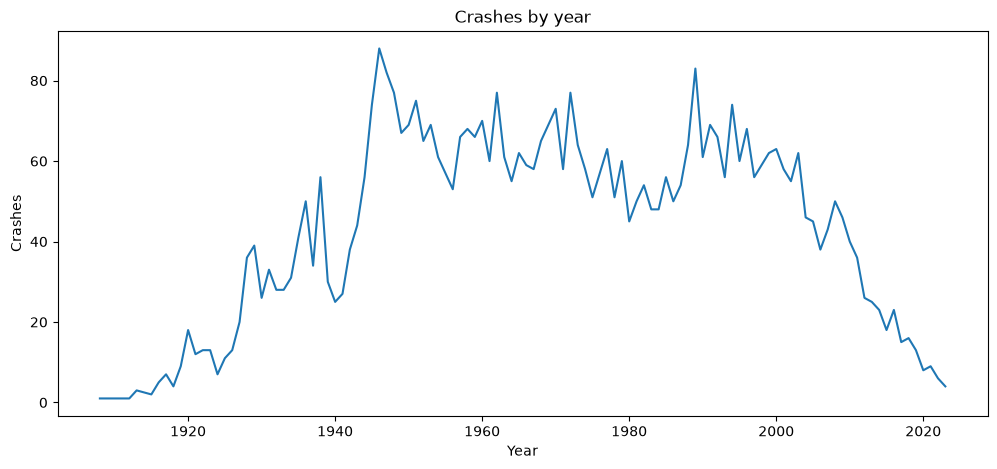

In [12]:
plt.figure(figsize=(12, 5))
df.groupby('Year').size().plot(kind='line')
plt.title('Crashes by year')
plt.xlabel('Year')
plt.ylabel('Crashes')
plt.show()

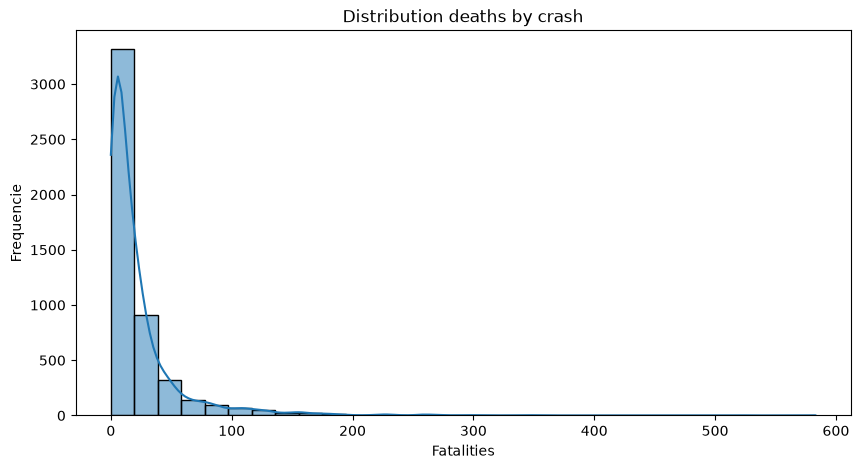

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Fatalities'].dropna(), bins=30, kde=True)
plt.title('Distribution deaths by crash')
plt.xlabel('Fatalities')
plt.ylabel('Frequencie')
plt.show()

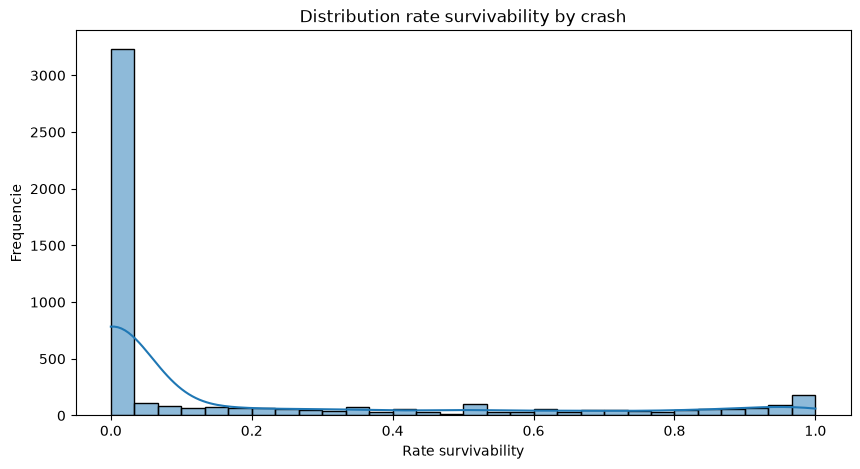

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(survival_rate, bins=30, kde=True)
plt.title('Distribution rate survivability by crash')
plt.xlabel('Rate survivability')
plt.ylabel('Frequencie')
plt.show()

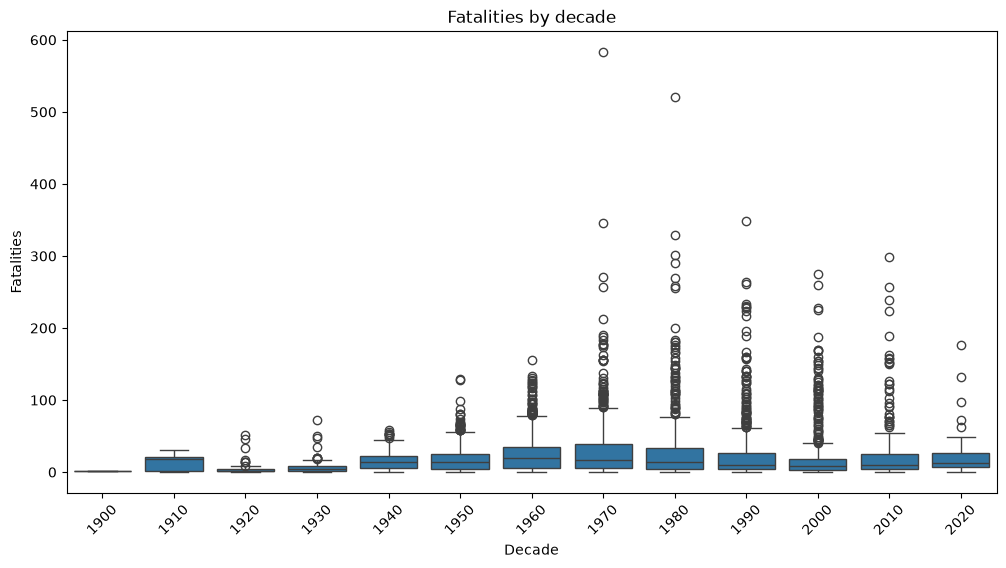

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Decade', y='Fatalities', data=df)
plt.title('Fatalities by decade')
plt.xlabel('Decade')
plt.ylabel('Fatalities')
plt.xticks(rotation=45)
plt.show()

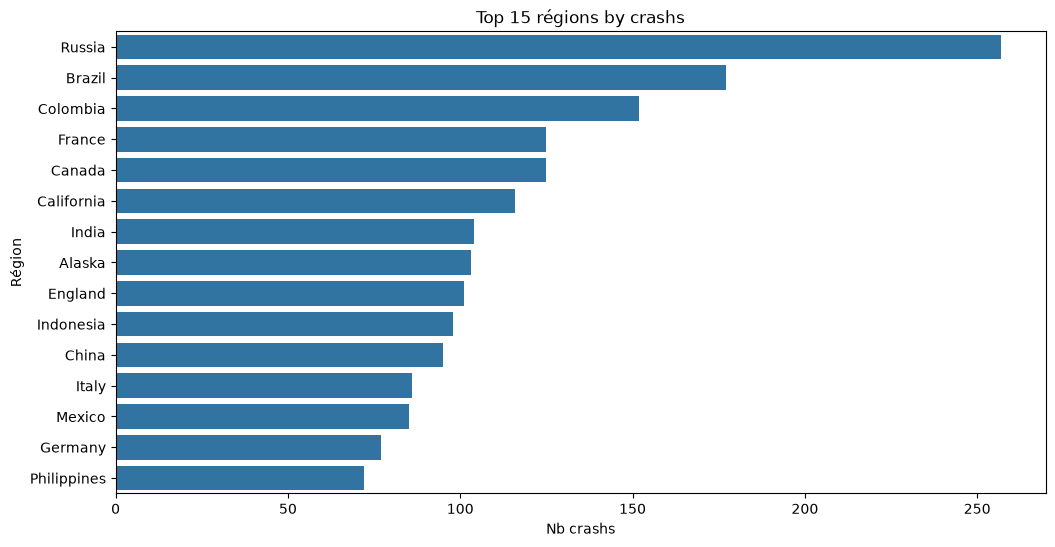

In [16]:
df['Region'] = df['Location'].str.split(',').str[-1].str.strip()

top_regions = df['Region'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_regions.values, y=top_regions.index)
plt.title('Top 15 régions by crashs')
plt.xlabel('Nb crashs')
plt.ylabel('Région')
plt.show()

5. Insight and Report:

    - Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
    - Prepare a well-structured report including all code, visualizations, and interpretations.


Analyse of crashs between 1908 and 2023.